In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import sys
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime as dt

sys.path.append('..')
file_path = '../data/processed/notebooks/master_analytical_file.parquet'

if os.path.exists(file_path):
    df_master = pd.read_parquet(file_path)
    print(f"Loaded Master Data: {len(df_master):,} rows")
    print(f"Date range: {df_master['shipped_dt'].min()} to {df_master['shipped_dt'].max()}")
else:
    print("Error: Master file not found. Please run Notebook 02 first.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded Master Data: 1,983,549 rows
Date range: 2025-01-01 00:00:00.275000 to 2025-12-31 21:40:11


In [4]:
df_labels = df_master.groupby('trade_account_id').agg(
    target=('type', lambda x:1 if 'SALE' in x.values else 0)
)

In [7]:
df_features = df_master.groupby('trade_account_id').agg(
    total_samples=('type', lambda x: (x=='SAMPLE').sum()),
    unique_motifs=('motif', 'nunique'),
    avg_item_price=('price_usd', 'mean'),
    showroom_share=('origin', lambda x: (x=='Showroom').mean()),
    days_since_first_sample=('shipped_dt', lambda x: (x.max() - x.min()).days)
)
df_final = df_features.join(df_labels)

In [8]:
# Calculate the ratio for XGBoost's scale_pos_weight
neg = len(df_final[df_final['target'] == 0])
pos = len(df_final[df_final['target'] == 1])
imbalance_ratio = neg / pos

print(f"Imbalance Ratio: {imbalance_ratio:.2f}")
# You'll use this ratio in the XGBoost parameters

Imbalance Ratio: 0.53


In [17]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc


import numpy as np
import scipy
try:
    from scipy import interp
except ImportError:
    from numpy import interp
    scipy.interp = interp

import scikitplot as skplt

[0]	validation_0-aucpr:0.90431
[100]	validation_0-aucpr:0.92040
[200]	validation_0-aucpr:0.92298
[300]	validation_0-aucpr:0.92463
[400]	validation_0-aucpr:0.92514
[500]	validation_0-aucpr:0.92553
[600]	validation_0-aucpr:0.92569
[700]	validation_0-aucpr:0.92598
[782]	validation_0-aucpr:0.92600


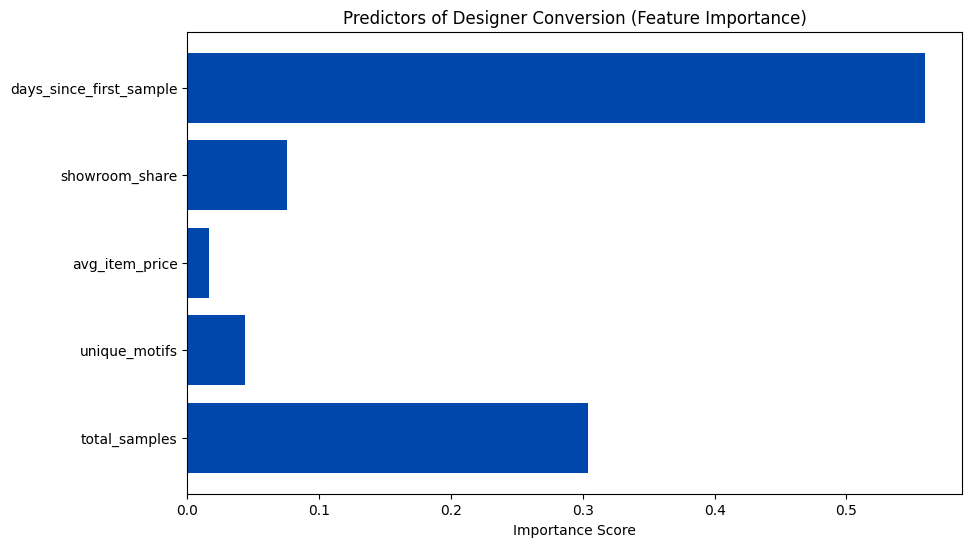

In [18]:
X = df_final.drop('target', axis=1)
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    scale_pos_weight=1.88,
    eval_metric='aucpr',
    early_stopping_rounds=50
)

model.fit(X_train, y_train, 
        eval_set=[(X_test, y_test)], 
        verbose=100)

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance, color='#0047AB')
plt.title('Predictors of Designer Conversion (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

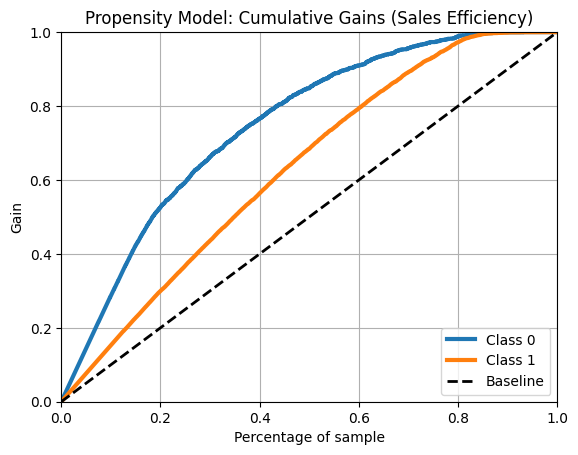

In [19]:
y_probas = model.predict_proba(X_test)
skplt.metrics.plot_cumulative_gain(y_test, y_probas)
plt.title('Propensity Model: Cumulative Gains (Sales Efficiency)')
plt.show()

In [20]:
df_final['propensity_score'] = model.predict_proba(X)[:, 1]

# Define Priority Tiers
df_final['priority_tier'] = pd.qcut(
    df_final['propensity_score'], 
    q=[0, 0.7, 0.9, 0.98, 1], 
    labels=['Standard', 'Nurture', 'High Priority', 'Immediate White-Glove']
)

# Display the top targets
print("--- TOP 10 PRIORITY TRADE ACCOUNTS ---")
print(df_final.sort_values('propensity_score', ascending=False).head(10))

--- TOP 10 PRIORITY TRADE ACCOUNTS ---
                  total_samples  unique_motifs  avg_item_price  \
trade_account_id                                                 
729295                        0              5      189.000000   
663302                        0              4      178.500000   
726498                        0              3       84.000000   
716177                        0              3      104.666667   
731281                        0              3      128.000000   
635657                        0              3      126.666667   
726769                        0              3      104.666667   
669265                        0              3      128.000000   
730819                        0              3      116.666667   
729892                        0              3      120.000000   

                  showroom_share  days_since_first_sample  target  \
trade_account_id                                                    
729295                       0

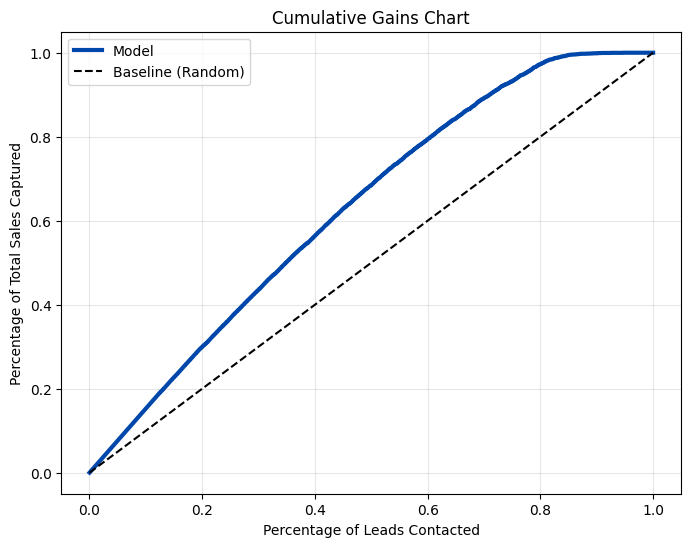

In [21]:
def plot_cumulative_gains(y_true, y_probs, title='Cumulative Gains Chart'):
    # Sort data by probability descending
    df = pd.DataFrame({'true': y_true, 'prob': y_probs}).sort_values('prob', ascending=False)
    df['cumulative_true'] = df['true'].cumsum() / df['true'].sum()
    df['percentage_of_population'] = np.arange(1, len(df) + 1) / len(df)
    
    plt.figure(figsize=(8, 6))
    plt.plot(df['percentage_of_population'], df['cumulative_true'], label='Model', color='#0047AB', lw=3)
    plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random)')
    plt.xlabel('Percentage of Leads Contacted')
    plt.ylabel('Percentage of Total Sales Captured')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Use it like this:
y_probs = model.predict_proba(X_test)[:, 1]
plot_cumulative_gains(y_test, y_probs)

In [23]:
df_master['shipped_dt'] = pd.to_datetime(df_master['shipped_dt'])


df_time_features = df_master.groupby('trade_account_id').agg(
    recency_days=('shipped_dt', lambda x: (df_master['shipped_dt'].max() - x.max()).days),
    sample_velocity_30d=('shipped_dt', lambda x: x[x > (x.max() - pd.Timedelta(days=30))].count()),
    avg_days_between_samples=('shipped_dt', lambda x: x.sort_values().diff().dt.days.mean()),
    first_interaction_age=('shipped_dt', lambda x: (df_master['shipped_dt'].max() - x.min()).days)
).fillna(0)

In [24]:
observation_date = df_master['shipped_dt'].max() - pd.Timedelta(days=30)

df_train_features = df_master[df_master['shipped_dt'] <= observation_date].groupby('trade_account_id').agg(
    recency_days=('shipped_dt', lambda x: (observation_date - x.max()).days),
    sample_velocity_30d=('shipped_dt', lambda x: x[x > (observation_date - pd.Timedelta(days=30))].count()),
)

future_sales = df_master[df_master['shipped_dt'] > observation_date]
future_sale_ids = future_sales[future_sales['type'] == 'SALE']['trade_account_id'].unique()

df_train_features['target_next_30d'] = df_train_features.index.isin(future_sale_ids).astype(int)

In [25]:
X = df_train_features.drop('target_next_30d', axis=1)
y = df_train_features['target_next_30d']

pos_weight = (len(y) - y.sum()) / y.sum()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model_temporal = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

model_temporal.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-logloss:0.68308
[100]	validation_0-logloss:0.57248
[200]	validation_0-logloss:0.57113
[300]	validation_0-logloss:0.57044
[400]	validation_0-logloss:0.57035
[499]	validation_0-logloss:0.57060


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

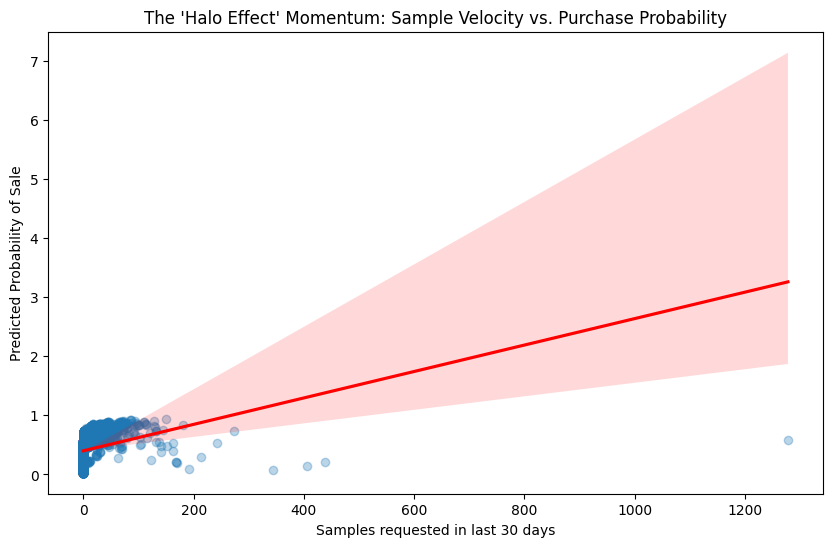

In [26]:
y_probs = model_temporal.predict_proba(X_val)[:, 1]
temp_results = X_val.copy()
temp_results['prob'] = y_probs

plt.figure(figsize=(10,6))
sns.regplot(data=temp_results, x='sample_velocity_30d', y='prob', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("The 'Halo Effect' Momentum: Sample Velocity vs. Purchase Probability")
plt.xlabel("Samples requested in last 30 days")
plt.ylabel("Predicted Probability of Sale")
plt.show()

In [ ]:
df_train_features['purchase_probability'] = model_temporal.predict_proba(X)[:, 1]
hot_list = df_train_features[df_train_features['purchase_probability'] > 0.8].sort_values('recency_days')

print("TOP 5 SALES TRIGGERS FOR THE NEXT 7 DAYS")
print(hot_list[['purchase_probability', 'recency_days', 'sample_velocity_30d']].head())

TOP 5 SALES TRIGGERS FOR THE NEXT 7 DAYS
                  purchase_probability  recency_days  sample_velocity_30d
trade_account_id                                                         
731201                        0.808341             0                   18
626415                        0.884612             0                  112
731085                        0.900241             0                  156
630097                        0.959709             0                  314
630744                        0.811409             0                   90


In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")